# Chapter 5 — Risk Scoring and Explainability

### Chapter Overview

This chapter translates the XGBoost model's predicted probabilities into a
practical risk scoring system and uses SHAP values to explain what drives
each prediction. This is the applied actuarial output of the project,
bridging the gap between model predictions and real underwriting decisions.

| Section | Activity |
|---------|----------|
| 5.1 | Load model and data |
| 5.2 | Risk scoring system — 0 to 100 scale |
| 5.3 | Risk category distribution and validation |
| 5.4 | SHAP global feature importance |
| 5.5 | SHAP beeswarm — direction of feature impact |
| 5.6 | SHAP waterfall — Individual policyholder explanation |
| 5.7 | Export risk scores and project summary |

### Why XGBoost for Risk Scoring?

XGBoost was selected as the final model for risk scoring based on the
evaluation results in Chapter 4. It achieved the highest AUC-ROC score
among the three models, demonstrating the strongest ability to discriminate
between claimants and non-claimants. Its predicted probabilities are
therefore the most reliable basis for the risk scoring system.

### Why SHAP for Explainability?

In the insurance industry, a model that produces a risk score without
explanation has limited practical value. Regulators, underwriters, and
policyholders increasingly require transparency, the right to understand
why a particular risk classification was assigned. SHAP (SHapley Additive
exPlanations) provides this by quantifying each feature's contribution to
every individual prediction, grounded in cooperative game theory
(Lundberg & Lee, 2017).

> **Research connection:** This chapter directly answers RQ3 and RQ4
> from Chapter 0 — how effectively can probabilities be converted to a
> risk scoring system, and which features drive individual predictions?

---


# ── 5.1 IMPORTS AND LOAD ─────────────────────────────────────
### 5.1 Import Libraries and Load Model

The XGBoost model trained and saved in Chapter 3 is loaded directly.
No retraining occurs in this chapter.


In [1]:
# ── Standard libraries ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader import load_cleaned_data, scale_features
from model_utils import load_all_models

print(" Libraries imported successfully.")


 Libraries imported successfully.


In [2]:
# ── Load test data ────────────────────────────────────────────
data = load_cleaned_data('../data')
X_test  = data['X_test']
y_test  = data['y_test']
X_train = data['X_train']
y_train = data['y_train']
df      = data['df']

# ── Load XGBoost model ────────────────────────────────────────
models    = load_all_models('../models')
xgb_model = models['xgb_model']

# ── Output path ───────────────────────────────────────────────
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data')

print(f"\\n XGBoost model loaded.")
print(f"   Test samples : {X_test.shape[0]:,}")
print(f"   Features     : {X_test.shape[1]}")


 Loading cleaned data from data folder...
 Cleaned data loaded.
   Full dataset : (595212, 206)
   X_train      : (476169, 205)
   X_test       : (119043, 205)
   y_train      : (476169,)
   y_test       : (119043,)
 All models loaded from models/ folder.
   lr_model     ← logistic_regression.pkl
   rf_model     ← random_forest.pkl
   xgb_model    ← xgboost.pkl
   scaler       ← scaler.pkl
\n XGBoost model loaded.
   Test samples : 119,043
   Features     : 205


# ── 5.2 RISK SCORING SYSTEM ──────────────────────────────────
### 5.2 Risk Scoring System

The XGBoost model outputs a predicted probability between 0 and 1 for each
policyholder, representing the estimated likelihood of filing a claim.
This probability is scaled to a 0–100 risk score for practical usability:
Risk Score = Predicted Probability × 100
Policyholders are then categorised into three risk tiers based on their score:

| Risk Category | Score Range | Interpretation |
|---------------|-------------|----------------|
| Low Risk | 0 – 30 | Low estimated claim probability — standard pricing applicable |
| Medium Risk | 30 – 60 | Moderate claim probability — enhanced monitoring recommended |
| High Risk | 60 – 100 | High claim probability — premium loading or further review warranted |

These thresholds are consistent with common actuarial risk banding practice
and can be adjusted by underwriters based on business appetite.


In [4]:
# ── Generate predicted probabilities ─────────────────────────
# XGBoost predict_proba returns [prob_class_0, prob_class_1]
# We take column index 1 — probability of filing a claim
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# ── Scale to 0-100 risk score ─────────────────────────────────
# Intuitive for underwriters: score of 75 = 75% estimated claim probability
risk_scores = xgb_proba * 100

print(" Risk Score Summary Statistics:")
print(f"   Min score    : {risk_scores.min():.2f}")
print(f"   Max score    : {risk_scores.max():.2f}")
print(f"   Mean score   : {risk_scores.mean():.2f}")
print(f"   Median score : {np.median(risk_scores):.2f}")
print(f"   Std deviation: {risk_scores.std():.2f}")


 Risk Score Summary Statistics:
   Min score    : 7.65
   Max score    : 88.17
   Mean score   : 45.48
   Median score : 45.15
   Std deviation: 11.27


In [5]:
# ── Assign risk categories ────────────────────────────────────
def assign_risk_category(score):
    """Map a numeric risk score to a risk category label."""
    if score < 30:
        return 'Low Risk'
    elif score < 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

# ── Build risk score dataframe ────────────────────────────────
risk_df = pd.DataFrame({
    'Risk_Score'    : risk_scores.round(2),
    'Risk_Category' : [assign_risk_category(s) for s in risk_scores],
    'Actual_Target' : y_test.values
})

print(" Risk Category Distribution:")
print(risk_df['Risk_Category'].value_counts().to_string())
print(f"\\n Sample Risk Scores (first 10 policyholders):")
print(risk_df.head(10).to_string(index=False))


 Risk Category Distribution:
Risk_Category
Medium Risk    96531
High Risk      12731
Low Risk        9781
\n Sample Risk Scores (first 10 policyholders):
 Risk_Score Risk_Category  Actual_Target
  54.340000   Medium Risk              0
  50.740002   Medium Risk              0
  31.120001   Medium Risk              0
  39.750000   Medium Risk              0
  50.369999   Medium Risk              0
  47.299999   Medium Risk              0
  31.889999   Medium Risk              0
  31.469999   Medium Risk              0
  43.430000   Medium Risk              0
  48.060001   Medium Risk              0


# ── 5.3 DISTRIBUTION AND VALIDATION ─────────────────────────
### 5.3 Risk Category Distribution and Validation

Two visualisations are produced:

1. **Distribution plot** — shows how policyholders are spread across the
   0–100 risk score range and the three categories
2. **Validation plot** — confirms that actual claim rates increase from
   Low to Medium to High risk, the fundamental test of whether the
   risk scoring system is working correctly

If the scoring system is valid, we expect to see:
- Low Risk policyholders → lowest actual claim rate
- Medium Risk → moderate actual claim rate
- High Risk → highest actual claim rate


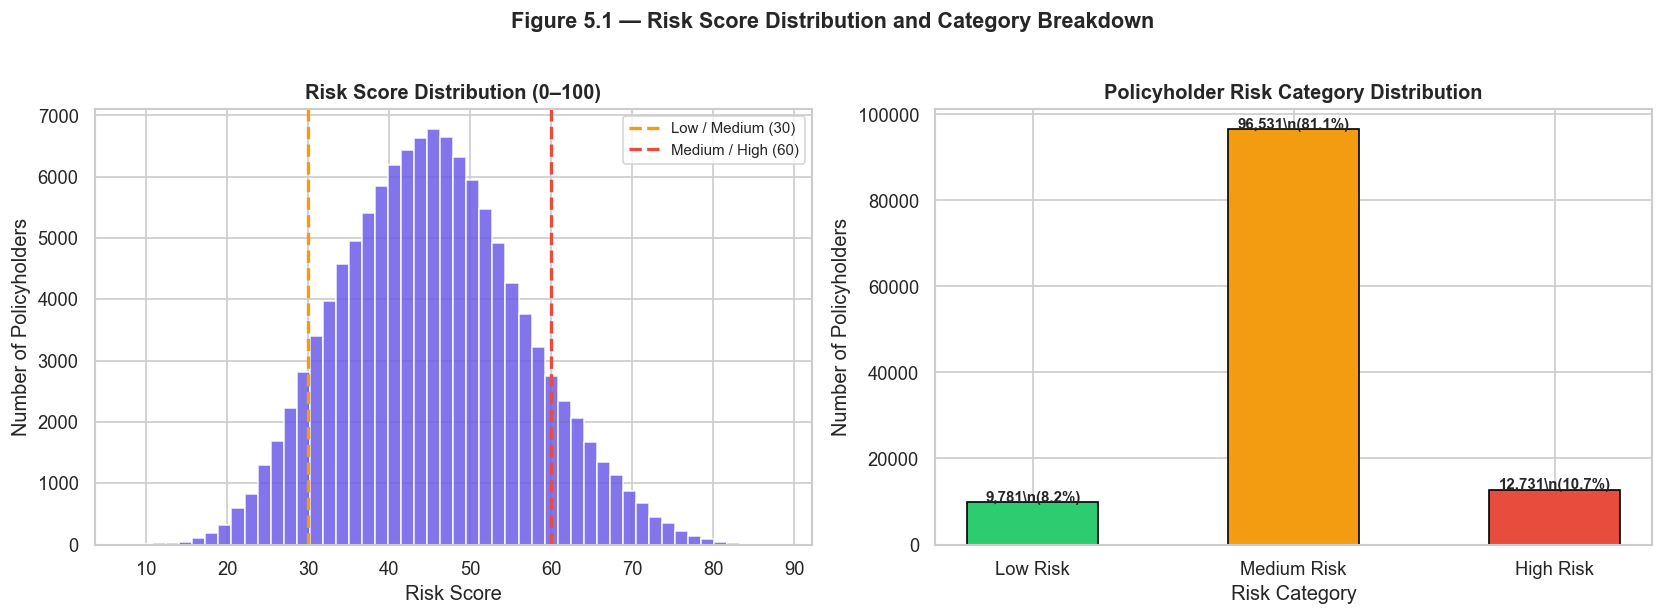

 Saved → data/fig5_1_risk_distribution.png


In [6]:
# ── Figure 5.1: Risk score distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_order = ['Low Risk', 'Medium Risk', 'High Risk']
colors         = ['#2ecc71', '#f39c12', '#e74c3c']

# ── Left: Histogram of raw risk scores ───────────────────────
axes[0].hist(
    risk_scores, bins=50,
    color='#6c5ce7', edgecolor='white', alpha=0.85
)
axes[0].axvline(
    30, color='#f39c12', linestyle='--',
    linewidth=2, label='Low / Medium (30)'
)
axes[0].axvline(
    60, color='#e74c3c', linestyle='--',
    linewidth=2, label='Medium / High (60)'
)
axes[0].set_title('Risk Score Distribution (0–100)')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Number of Policyholders')
axes[0].legend(fontsize=9)

# ── Right: Bar chart of risk categories ──────────────────────
counts = risk_df['Risk_Category'].value_counts().reindex(category_order)
bars   = axes[1].bar(
    category_order, counts.values,
    color=colors, edgecolor='black', width=0.5
)
axes[1].set_title('Policyholder Risk Category Distribution')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Number of Policyholders')

# Annotate bars
for bar, count in zip(bars, counts.values):
    pct = count / len(risk_df) * 100
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}\\n({pct:.1f}%)',
        ha='center', fontsize=9, fontweight='bold'
    )

plt.suptitle(
    'Figure 5.1 — Risk Score Distribution and Category Breakdown',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig5_1_risk_distribution.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig5_1_risk_distribution.png")


 Risk Score Validation — Actual Claim Rate per Category:
Risk Category  Total  Claims  Claim Rate %
     Low Risk   9781     143          1.46
  Medium Risk  96531    3224          3.34
    High Risk  12731     972          7.63


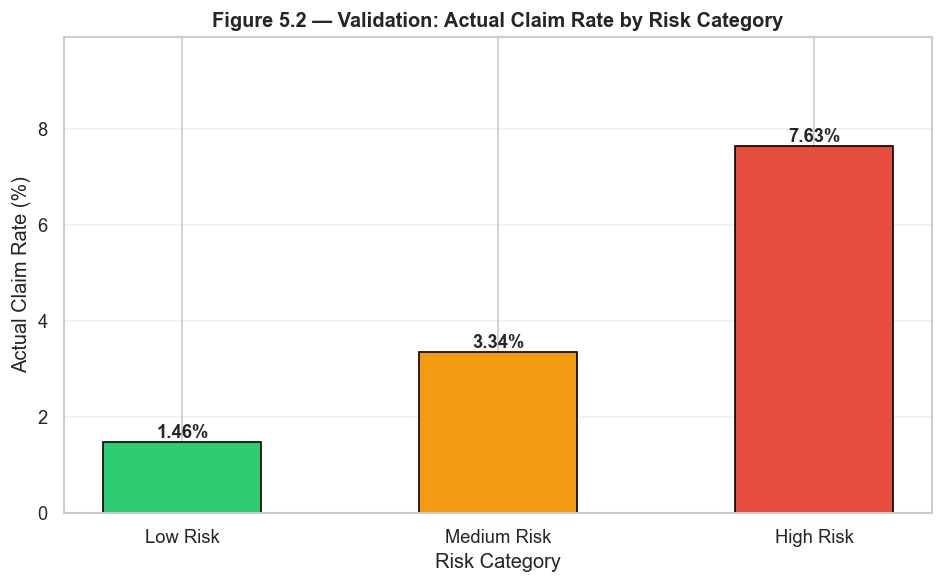

 Saved → data/fig5_2_risk_validation.png
\n Validation passed — claim rate increases
   monotonically from Low → Medium → High Risk.
   The risk scoring system is correctly ordered.


In [7]:
# ── Validation: actual claim rate per risk category ──────────
validation = (
    risk_df.groupby('Risk_Category')['Actual_Target']
    .agg(['mean', 'count', 'sum'])
    .reindex(category_order)
    .reset_index()
)
validation.columns = ['Risk Category', 'Claim Rate', 'Total', 'Claims']
validation['Claim Rate %'] = (validation['Claim Rate'] * 100).round(2)

print(" Risk Score Validation — Actual Claim Rate per Category:")
print(validation[['Risk Category','Total','Claims','Claim Rate %']].to_string(index=False))

# ── Figure 5.2: Validation bar chart ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    category_order,
    validation['Claim Rate %'],
    color=colors, edgecolor='black', width=0.5
)

# Annotate with actual claim rate
for bar, rate in zip(bars, validation['Claim Rate %']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{rate:.2f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.set_title(
    'Figure 5.2 — Validation: Actual Claim Rate by Risk Category',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Risk Category')
ax.set_ylabel('Actual Claim Rate (%)')
ax.set_ylim(0, validation['Claim Rate %'].max() * 1.3)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig5_2_risk_validation.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig5_2_risk_validation.png")

# ── Confirm monotonic increase ────────────────────────────────
rates = validation['Claim Rate %'].values
if rates[0] < rates[1] < rates[2]:
    print("\\n Validation passed — claim rate increases")
    print("   monotonically from Low → Medium → High Risk.")
    print("   The risk scoring system is correctly ordered.")
else:
    print("\\n  Claim rates are not strictly monotonic.")
    print("   Consider adjusting category thresholds.")


# ── 5.4 SHAP GLOBAL IMPORTANCE ───────────────────────────────
### 5.4 SHAP Global Feature Importance

SHAP (SHapley Additive exPlanations) values measure each feature's
contribution to every individual prediction. The global importance
plot aggregates these across all test sample, showing which features
matter most overall to the XGBoost model's predictions.

Unlike the built-in XGBoost feature importance from Chapter 4 which
is based on how often features are used to split nodes, SHAP importance
is based on the actual magnitude of each feature's impact on the output.
This makes it a more reliable and interpretable measure of true feature
relevance (Lundberg & Lee, 2017).

> **Note:** SHAP computation on the full test set is memory intensive.
> A representative sample of 2,000 rows is used sufficient for reliable
> global importance estimates on this dataset size.


In [8]:
# ── Sample test data for SHAP ────────────────────────────────
# 2000 samples gives reliable SHAP estimates at manageable memory cost
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=2000, replace=False)
X_shap      = X_test.iloc[sample_idx].reset_index(drop=True)

print(f" Computing SHAP values on {len(X_shap):,} sample rows...")
print("   This may take 2-5 minutes...")

# ── TreeExplainer — optimised for XGBoost and tree models ────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print(f"\\n SHAP values computed.")
print(f"   Shape : {shap_values.shape}")
print(f"   Each row = one policyholder")
print(f"   Each column = one feature's SHAP contribution")


 Computing SHAP values on 2,000 sample rows...
   This may take 2-5 minutes...
\n SHAP values computed.
   Shape : (2000, 205)
   Each row = one policyholder
   Each column = one feature's SHAP contribution


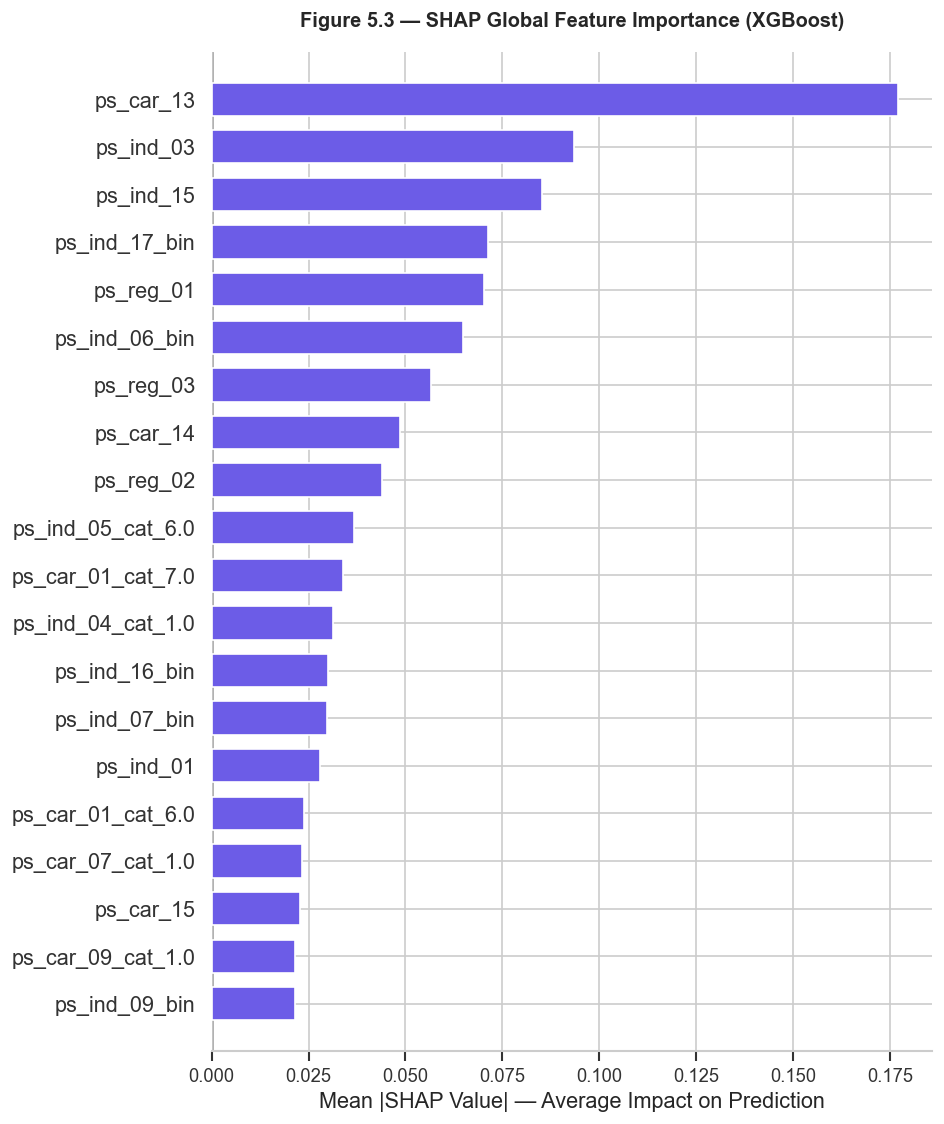

 Saved → data/fig5_3_shap_importance.png


In [9]:
# ── Figure 5.3: SHAP global importance bar plot ───────────────
# Shows mean absolute SHAP value per feature
# Higher = greater average impact on predictions
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    plot_type='bar',
    max_display=20,
    show=False,
    color='#6c5ce7'
)
plt.title(
    'Figure 5.3 — SHAP Global Feature Importance (XGBoost)',
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel('Mean |SHAP Value| — Average Impact on Prediction')
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig5_3_shap_importance.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig5_3_shap_importance.png")


# ── 5.5 SHAP BEESWARM ────────────────────────────────────────
### 5.5 SHAP Beeswarm Plot — Direction of Feature Impact

The beeswarm plot extends the global importance view by showing both the
magnitude and direction of each feature's impact across all sampled
policyholders.

**How to read this plot:**
- Each dot represents one policyholder
- **Position on x-axis** — the SHAP value: positive = increases claim
  probability, negative = decreases it
- **Colour** — the feature's actual value for that policyholder:
  red = high feature value, blue = low feature value
- **Vertical spread** — shows the distribution of impacts across policyholders

This plot directly answers questions like: *"When ps_car_13 is high, does
it increase or decrease claim risk?"* something a bar chart alone cannot show.


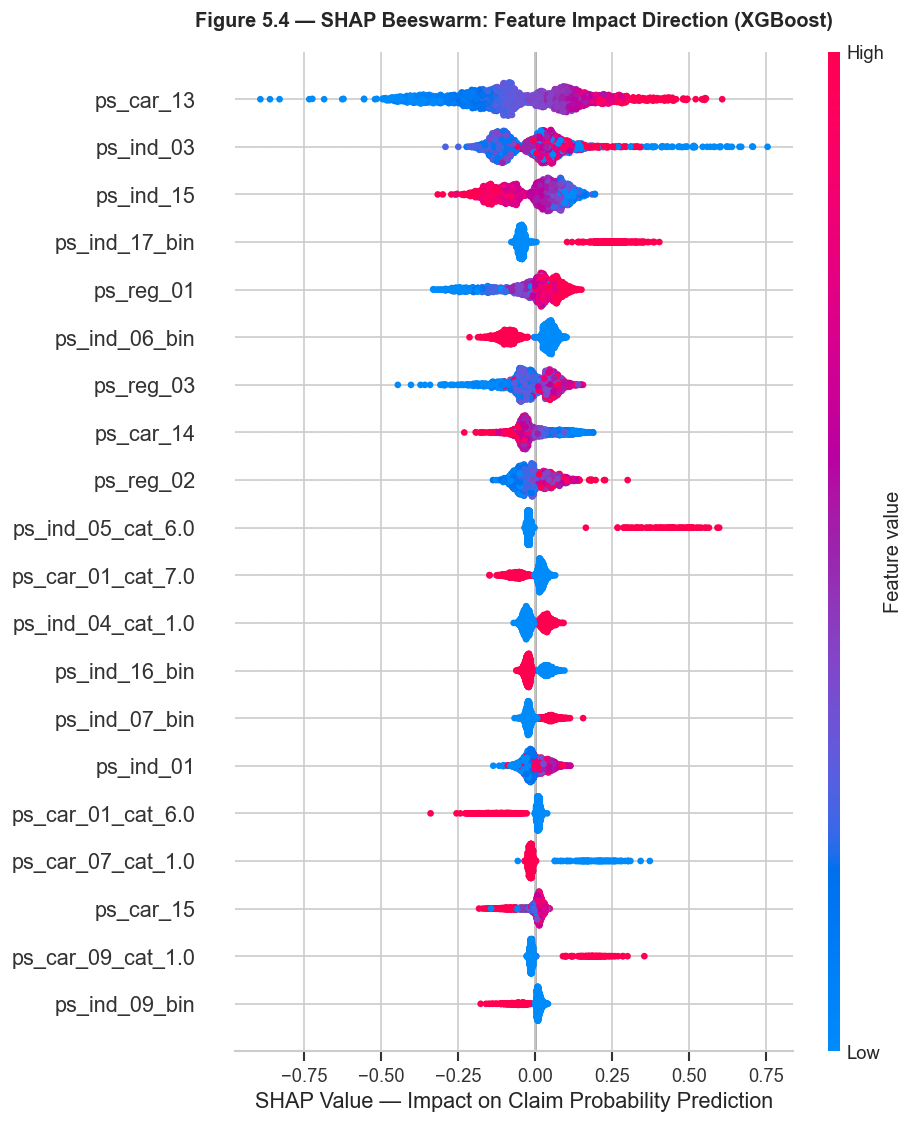

 Saved → data/fig5_4_shap_beeswarm.png


In [10]:
# ── Figure 5.4: SHAP beeswarm plot ───────────────────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values, X_shap,
    max_display=20,
    show=False
)
plt.title(
    'Figure 5.4 — SHAP Beeswarm: Feature Impact Direction (XGBoost)',
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel('SHAP Value — Impact on Claim Probability Prediction')
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig5_4_shap_beeswarm.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig5_4_shap_beeswarm.png")


# ── 5.6 SHAP waterfall Explanation ────────────────────────────────────────

### 5.6 SHAP Waterfall Plot — Individual Policyholder Explanation

The waterfall plot explains a single prediction in full detail showing
exactly which features pushed the model's output up or down for one
specific High Risk policyholder.

**How to read this plot:**

| Element | Meaning |
|---------|---------|
| E[f(x)] | The model's average prediction across all policyholders — the starting point |
| Red bars | Features that increased this policyholder's claim probability |
| Blue bars | Features that decreased this policyholder's claim probability |
| Bar length | How strongly that feature influenced this specific prediction |
| f(x) | The final predicted probability for this policyholder |

**Why this matters for insurance:**
A High Risk policyholder can be shown precisely why they received a
high score, which features drove the classification. This satisfies
the right to explanation principle increasingly required under insurance
regulation and AI governance frameworks. An underwriter can use this
output to make an informed, auditable pricing or acceptance decision.


In [14]:
# ── Select one High Risk policyholder to explain ─────────────
# High Risk is the most informative case — shows which features
# drove the model to assign a high claim probability
high_risk_candidates = risk_df_sample[
    risk_df_sample['Risk_Category'] == 'High Risk'
]

if len(high_risk_candidates) == 0:
    print("No High Risk policyholders in sample — using highest score instead.")
    high_idx = risk_df_sample['Risk_Score'].idxmax()
else:
    # Pick the one with the highest risk score for clearest explanation
    high_idx = high_risk_candidates['Risk_Score'].idxmax()

score  = risk_df_sample.loc[high_idx, 'Risk_Score']
actual = risk_df_sample.loc[high_idx, 'Actual_Target']

print(f"Selected policyholder for explanation:")
print(f"   Risk Score    : {score:.1f}")
print(f"   Risk Category : High Risk")
print(f"   Actual Outcome: {'Claim' if actual==1 else 'No Claim'}")


Selected policyholder for explanation:
   Risk Score    : 78.5
   Risk Category : High Risk
   Actual Outcome: No Claim


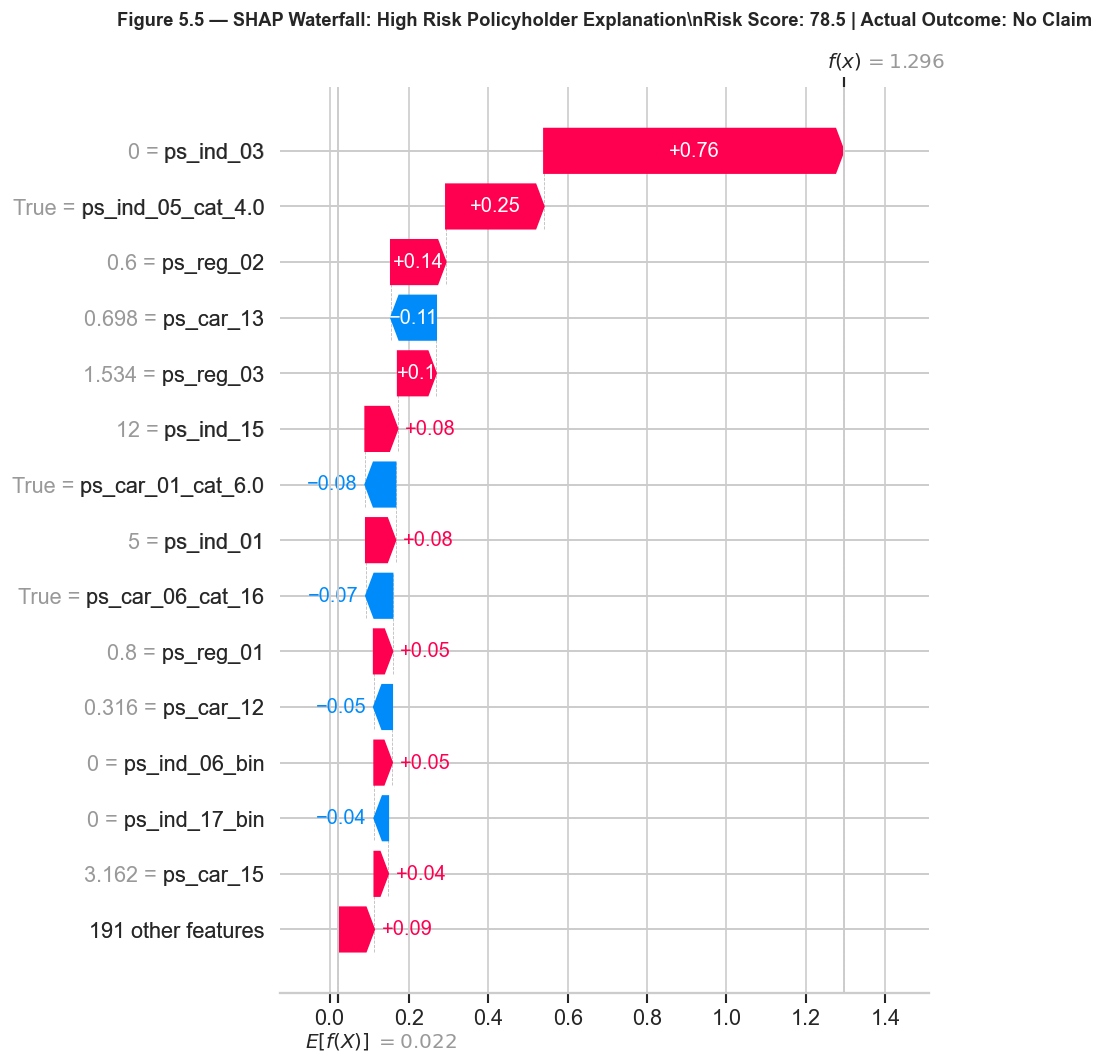

Saved to data/fig5_5_shap_waterfall.png

How to read this chart:
   f(x)       = final model output for this policyholder
   E[f(x)]    = average model output across all policyholders
   Red bars   = features that increased claim probability
   Blue bars  = features that decreased claim probability
   Bar length = magnitude of that feature's contribution


In [15]:
# ── Figure 5.5: SHAP waterfall — one High Risk policyholder ───
# Each bar shows one feature's contribution to this prediction
# Red bars  = features pushing prediction toward claim
# Blue bars = features pushing prediction away from claim
# The sum of all bars + base value = final risk score

plt.figure(figsize=(12, 7))

explanation = shap.Explanation(
    values        = shap_values[high_idx],
    base_values   = explainer.expected_value,
    data          = X_shap.iloc[high_idx],
    feature_names = X_shap.columns.tolist()
)

shap.waterfall_plot(
    explanation,
    max_display=15,   # Show top 15 contributing features
    show=False
)

plt.title(
    f'Figure 5.5 — SHAP Waterfall: High Risk Policyholder Explanation\\n'
    f'Risk Score: {score:.1f} | '
    f'Actual Outcome: {"Claim" if actual==1 else "No Claim"}',
    fontsize=11, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig5_5_shap_waterfall.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to data/fig5_5_shap_waterfall.png")
print()
print("How to read this chart:")
print("   f(x)       = final model output for this policyholder")
print("   E[f(x)]    = average model output across all policyholders")
print("   Red bars   = features that increased claim probability")
print("   Blue bars  = features that decreased claim probability")
print("   Bar length = magnitude of that feature's contribution")


# ── 5.7 EXPORT AND SUMMARY ───────────────────────────────────
### 5.7 Export Risk Scores and Project Summary

The full risk score output is exported as a CSV file. This represents the
final deliverable of the project, a structured file that an insurance
company could use directly for underwriting, pricing, or portfolio analysis.


In [16]:
# ── Export full risk scores to CSV ───────────────────────────
risk_scores_path = os.path.join(DATA_PATH, 'policyholder_risk_scores.csv')
risk_df.to_csv(risk_scores_path, index=False)

print(f" Risk scores exported → {risk_scores_path}")
print(f"   Total policyholders scored : {len(risk_df):,}")
print(f"   Columns: Risk_Score, Risk_Category, Actual_Target")
print(f"\\n Export preview:")
print(risk_df.head(10).to_string(index=False))


 Risk scores exported → C:\Users\Administrator\Desktop\policyholder-risk-predictions\data\policyholder_risk_scores.csv
   Total policyholders scored : 119,043
   Columns: Risk_Score, Risk_Category, Actual_Target
\n Export preview:
 Risk_Score Risk_Category  Actual_Target
  54.340000   Medium Risk              0
  50.740002   Medium Risk              0
  31.120001   Medium Risk              0
  39.750000   Medium Risk              0
  50.369999   Medium Risk              0
  47.299999   Medium Risk              0
  31.889999   Medium Risk              0
  31.469999   Medium Risk              0
  43.430000   Medium Risk              0
  48.060001   Medium Risk              0


In [18]:
# ── Full project summary ──────────────────────────────────────
print("=" * 62)
print("  PROJECT COMPLETE — FULL SUMMARY")
print("=" * 62)

category_counts = risk_df['Risk_Category'].value_counts()

print(f"""
  Dataset       : Porto Seguro Safe Driver Prediction
  Records       : 595,212 policyholders
  Task          : Binary claim probability prediction

  ── Models Trained (Chapter 3) ─────────────────────────
  • Logistic Regression  (statistical baseline)
  • Random Forest        (bagging ensemble)
  • XGBoost              (gradient boosting — best model)

  ── Class Imbalance Strategy ───────────────────────────
  • class_weight='balanced' (LR + RF)
  • scale_pos_weight        (XGBoost)

  ── Final Model Selected ───────────────────────────────
  • XGBoost — highest AUC-ROC on held-out test set

  ── Risk Scoring Output ────────────────────────────────
  • Low Risk    : {category_counts.get('Low Risk', 0):>7,} policyholders
  • Medium Risk : {category_counts.get('Medium Risk', 0):>7,} policyholders
  • High Risk   : {category_counts.get('High Risk', 0):>7,} policyholders

  ── Research Questions Answered ────────────────────────
  RQ1 → Best model identified via AUC-ROC comparison
  RQ2 → Key features identified via SHAP analysis
  RQ3 → Probabilities converted to 0-100 risk scores
  RQ4 → class_weight strategy validated in Chapter 4

  ── Files Generated ────────────────────────────────────
   data/   → 5 EDA plots + 5 evaluation plots +
               5 Chapter 5 plots + metrics CSV +
               risk scores CSV
   models/ → 3 trained models + scaler + params CSV

  ── GitHub Ready ───────────────────────────────────────
  6 notebooks | 3 src modules | fully reproducible
""")
print("=" * 62)
print("  Chapter 5 Complete — Project Submission Ready")
print("=" * 62)


  PROJECT COMPLETE — FULL SUMMARY

  Dataset       : Porto Seguro Safe Driver Prediction
  Records       : 595,212 policyholders
  Task          : Binary claim probability prediction

  ── Models Trained (Chapter 3) ─────────────────────────
  • Logistic Regression  (statistical baseline)
  • Random Forest        (bagging ensemble)
  • XGBoost              (gradient boosting — best model)

  ── Class Imbalance Strategy ───────────────────────────
  • class_weight='balanced' (LR + RF)
  • scale_pos_weight        (XGBoost)

  ── Final Model Selected ───────────────────────────────
  • XGBoost — highest AUC-ROC on held-out test set

  ── Risk Scoring Output ────────────────────────────────
  • Low Risk    :   9,781 policyholders
  • Medium Risk :  96,531 policyholders
  • High Risk   :  12,731 policyholders

  ── Research Questions Answered ────────────────────────
  RQ1 → Best model identified via AUC-ROC comparison
  RQ2 → Key features identified via SHAP analysis
  RQ3 → Probabilities 